In [1]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque

from torch.utils.tensorboard import SummaryWriter
version = "v2.4.6b"
writer = SummaryWriter(f"runs/spaceship_{version}")  

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本
script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game
from Env import SpaceShipEnv

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
True
12.8
90701


In [2]:
# Hyperparameters
num_episodes = 4000
batch_size = 64
gamma = 0.99
lr = 1e-4
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.999
memory_capacity = 60000  # 100000
target_update_freq = 2000   # 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


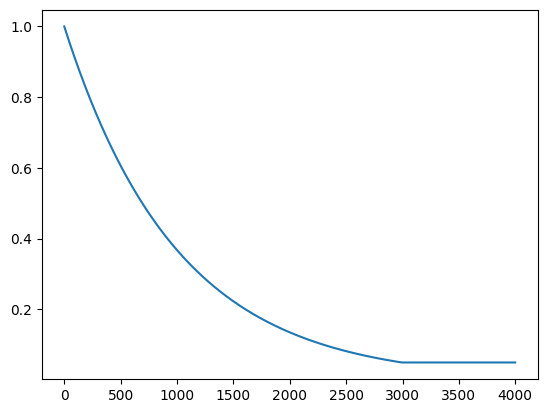

In [3]:
epsilon_list=[]
epsilon=epsilon_start
for i in range(num_episodes):
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    epsilon_list.append(epsilon)
plt.plot(epsilon_list)

In [4]:
class MLPDDQN(nn.Module):
    def __init__(self, input_dim, num_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
    def forward(self, x):
        return self.net(x)

In [19]:
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree  = np.zeros(2*capacity - 1, dtype=np.float32)
        self.data  = [None]*capacity
        self.write = 0
        self.n     = 0

    # -- internal helpers --
    def _propagate(self, idx, delta):
        parent = (idx - 1)//2
        self.tree[parent] += delta
        if parent: self._propagate(parent, delta)

    def _retrieve(self, idx, s):
        left = 2*idx + 1
        right = left + 1
        if left >= len(self.tree): return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        else:
            return self._retrieve(right, s-self.tree[left])

    # -- public API --
    @property
    def total(self): return self.tree[0]

    def add(self, p, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, p)
        self.write = (self.write + 1) % self.capacity
        self.n = min(self.n+1, self.capacity)

    def update(self, idx, p):
        delta = p - self.tree[idx]
        self.tree[idx] = p
        self._propagate(idx, delta)

    def get(self, s):
        idx = self._retrieve(0, s)
        dataIdx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[dataIdx]
    
class PrioritizedReplay:
    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_frames=1e5):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta  = beta_start
        self.beta_inc = (1.0-beta_start)/beta_frames
        self.eps   = 1e-6              # 避免 p=0
        self.max_p = 1.0               # 新 transition 用

    def push(self, state, action, reward, next_state, done):
        """ now accepts five args just like ReplayMemory """
        # pack them into a single 'data' tuple
        data = (state, action, reward, next_state, done)
        # compute a default priority (e.g. max existing priority or 1.0)
        self.tree.add(self.max_p , data)

    def sample(self, batch_size):
        batch, idxs, weights = [], [], []
        seg = self.tree.total / batch_size
        self.beta = min(1.0, self.beta + self.beta_inc)

        
        for i in range(batch_size):
            a, b = seg*i, seg*(i+1)
            s = np.random.uniform(a, b)
            while True:
                s = random.uniform(a, b)
                idx, p, data = self.tree.get(s)
                if data is not None and p > 0:
                    break

            batch.append(data)
            idxs.append(idx)

        prob = p / self.tree.total
        weights.append((self.tree.n * prob) ** (-self.beta))
        weights = torch.tensor(weights, dtype=torch.float32, device=device)
        
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        # to tensor ONCE  ↓
        states      = torch.from_numpy(states).float().to(device)
        actions     = torch.from_numpy(actions).long().to(device)
        rewards     = torch.from_numpy(rewards).float().to(device)
        next_states = torch.from_numpy(next_states).float().to(device)
        dones       = torch.from_numpy(dones).float().to(device)

        return (states, actions, rewards, next_states, dones), idxs, weights

    def update_priorities(self, idxs, errors):
        errors = errors + self.eps
        self.max_p = max(self.max_p, errors.max())
        for idx, e in zip(idxs, errors):
            self.tree.update(idx, float(e ** self.alpha))

    def __len__(self):
        return self.tree.n

In [20]:
# 初始化
env = SpaceShipEnv()
num_actions = len(env.action_space)
state_dim    = env._extract_state().shape[0]   #
print(state_dim)

policy_net   = MLPDDQN(state_dim, num_actions).to(device)
target_net   = MLPDDQN(state_dim, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())  # 初始時讓目標網路等於策略網路
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
# memory = ReplayMemory(memory_capacity)
memory = PrioritizedReplay(memory_capacity)

51


In [21]:
# load the model

ckpt_path = f"{version}/checkpoint_epXXXX.pth"
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    policy_net.load_state_dict(ckpt["policy_net"])
    
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()          
    
    optimizer.load_state_dict(ckpt["optimizer"])
    start_episode  = ckpt["episode"] + 1
    total_steps    = ckpt["total_steps"]
    best_avg_score = ckpt["best_avg_score"]
    best_avg_reward= ckpt["best_avg_reward"]
    epsilon = ckpt["epsilon"]
    reward_history = ckpt['reward_history']
    score_history = ckpt['score_history']
    score_window  = deque(score_history[-100:],  maxlen=100)
    reward_window = deque(reward_history[-100:], maxlen=100)
    memory.buffer = deque(list(memory.buffer)[-memory_capacity//2:], maxlen=memory_capacity)
    print(f"Replay buffer shrunk to {len(memory)} transitions for new reward scale.")
    print(f"Loaded checkpoint from episode {start_episode}, best_avg_score: {best_avg_score:.2f}, epsilon={epsilon:.3f}")

else:
    start_episode = 0
    total_steps = 0
    epsilon = epsilon_start
    reward_history = []
    score_history = []
    last_steps = 0

    score_window   = deque(maxlen=50)
    reward_window  = deque(maxlen=50)
    best_avg_score = float('-inf')
    best_avg_reward = float('-inf')

# Training loop
for episode in range(start_episode, 4000):
    state_np = env.reset()
    state    = torch.tensor(state_np, dtype=torch.float32, device=device)
    total_reward, done = 0.0, False
    total_loss, update_cnt = 0.0, 0                  

    while not done:
        # ---------- ε-greedy ----------
        if random.random() < epsilon:
            action = random.randrange(num_actions)
        else:
            with torch.no_grad():
                action = policy_net(state.unsqueeze(0)).argmax(1).item()

        # ---------- 執行動作 ----------
        next_state_np, reward, done, score = env.step(action)
        next_state = torch.tensor(next_state_np, dtype=torch.float32, device=device)

        total_reward += reward
        memory.push(state.cpu().numpy(), action, reward, next_state.cpu().numpy(), done)
        

        state = next_state

        # ---------- 取 batch 訓練 ----------
        if len(memory) >= batch_size:
            (states, actions, rewards, next_states, dones), idxs, weights = memory.sample(batch_size)

            with torch.no_grad():
                next_act = policy_net(next_states).argmax(1).unsqueeze(1)
                next_q   = target_net(next_states).gather(1, next_act).squeeze(1)
                target_q = rewards + gamma * next_q * (1 - dones)

            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            td_err = (target_q - current_q).detach().abs()

            loss_element = F.smooth_l1_loss(current_q, target_q, reduction='none')              # Huber
            loss = (weights * loss_element).mean()                            # ✔ ③ 
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
            optimizer.step()
            new_prios = td_err.cpu().numpy()
            memory.update_priorities(idxs, new_prios)

        # ---------- 更新 target ----------
        total_steps += 1
        if total_steps % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    episode_steps = total_steps - last_steps
    last_steps = total_steps

    # 更新 epsilon 並紀錄統計資料 / Decay epsilon and log results
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    reward_history.append(total_reward)
    score_history.append(score)
    
    score_window.append(score)
    reward_window.append(total_reward)

    reward_eff = total_reward / episode_steps
    score_eff = score / episode_steps
    
    avg_score  = sum(score_window)  / len(score_window)
    avg_reward = sum(reward_window) / len(reward_window)
    avg_loss = total_loss / update_cnt if update_cnt else 0   # ★新增

    # ---------- ★ 1. 儲存 best 平均 Score ----------
    if avg_score > best_avg_score and len(score_window)==50:
        best_avg_score = avg_score
        torch.save({"policy_net": policy_net.state_dict()}, f"{version}/best_avg_score.pth")
        print(f"  ↑ New best 50-avg SCORE: {best_avg_score:.1f} saved.")

    # ---------- ★ 2. 儲存 best 平均 Reward ----------
    if avg_reward > best_avg_reward and len(reward_window)==50:
        best_avg_reward = avg_reward
        torch.save({"policy_net": policy_net.state_dict()}, f"{version}/best_avg_reward.pth")
        print(f"  ↑ New best 50-avg REWARD: {best_avg_reward:.1f} saved.")

    print(f"E{episode+1:4d} | St:{episode_steps:7d} | R:{total_reward:7.2f} | RE:{reward_eff:7.2f} | AR:{avg_reward:7.2f} | S:{score:5d} | SE:{score_eff:7.2f} "
          f"| AS:{avg_score:6.0f} | ε:{epsilon:.3f}")
    
    writer.add_scalar("Reward/episode", total_reward, episode)
    writer.add_scalar("Score/episode", score, episode)
    writer.add_scalar("Loss/episode",   avg_loss,   episode)
    writer.add_scalar("Epsilon/episode", epsilon,   episode)

    writer.add_scalar("Reward/total",      total_reward, episode)
    writer.add_scalar("Score/total",       score,        episode)
    writer.add_scalar("Reward/reward_e",    reward_eff, episode)
    writer.add_scalar("Reward/avg50",      avg_reward,   episode)
    writer.add_scalar("Score/avg50",       avg_score,    episode)
    writer.add_scalar("Score_e/score_e",     score_eff, episode)
    writer.add_scalar("Reward/best_avg",   best_avg_reward, episode)
    writer.add_scalar("Score/best_avg",    best_avg_score,  episode)
    writer.add_scalar("Loss/avg",          avg_loss,  episode)
    writer.add_scalar("Epsilon",           epsilon,      episode)

    # -----（可選）每 10 集同步到磁碟-----
    if (episode + 1) % 10 == 0:
        writer.flush()


    # ---------- ★ 3. 每 50 集完整 checkpoint ----------
    if (episode + 1) % 50 == 0:
        ckpt_path = f"{version}/checkpoint_ep{episode+1:04d}.pth"
        torch.save({
            "policy_net": policy_net.state_dict(),
            "target_net": target_net.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "epsilon":    epsilon,
            "episode":    episode,
            "total_steps": total_steps,
            "best_avg_score":  best_avg_score,
            "best_avg_reward": best_avg_reward,
            'reward_history': reward_history,
            'score_history': score_history,
        }, ckpt_path)

        print(f"  ⌁ 50-ep checkpoint saved to {ckpt_path}")

env.close()
writer.close()

E   1 | St:   1009 | R: -67.90 | RE:  -0.07 | AR: -67.90 | S:  590 | SE:   0.58 | AS:   590 | ε:0.999
E   2 | St:    630 | R:-263.10 | RE:  -0.42 | AR:-165.50 | S:  266 | SE:   0.42 | AS:   428 | ε:0.998
E   3 | St:    553 | R:-203.13 | RE:  -0.37 | AR:-178.04 | S:  214 | SE:   0.39 | AS:   357 | ε:0.997
E   4 | St:    555 | R:-151.58 | RE:  -0.27 | AR:-171.43 | S:  280 | SE:   0.50 | AS:   338 | ε:0.996
E   5 | St:   1233 | R: -76.38 | RE:  -0.06 | AR:-152.42 | S:  714 | SE:   0.58 | AS:   413 | ε:0.995
E   6 | St:    594 | R:-178.47 | RE:  -0.30 | AR:-156.76 | S:  294 | SE:   0.49 | AS:   393 | ε:0.994
E   7 | St:   1016 | R:-296.04 | RE:  -0.29 | AR:-176.66 | S:  406 | SE:   0.40 | AS:   395 | ε:0.993
E   8 | St:   1122 | R:-183.42 | RE:  -0.16 | AR:-177.50 | S:  496 | SE:   0.44 | AS:   408 | ε:0.992
E   9 | St:    591 | R:-149.72 | RE:  -0.25 | AR:-174.42 | S:  364 | SE:   0.62 | AS:   403 | ε:0.991
E  10 | St:    703 | R:-230.40 | RE:  -0.33 | AR:-180.01 | S:  348 | SE:   0.50 | 

KeyboardInterrupt: 